In [33]:
import numpy as np
import pandas as pd
from numpy.polynomial.polynomial import polyfit

from pathlib import Path

from itertools import chain

from response_stats.generators import PoissonSpikeGenerator
from response_stats.responses import ResponseConfig, make_response_data, ResponseDetector
from response_stats.responses.response_tests import WilcoxonTest, SurrogateTest

from response_stats.plot_utils import *

import matplotlib.pyplot as plt

from scipy.stats import pearsonr

data_dir = Path("/media/al/darch/response_stats/datasets/tests/response_trials[5, 500]/response_10000samples_example.yaml-config_2026-01-16_15-06-15.parquet")

In [34]:
data = pd.read_parquet(data_dir)

In [35]:
data

,n_trials,n_supp_trials,response,fr_baseline,fr_response,latency,duration,time_baseline,time_stimulus,refractory_period_induced,beta_a,beta_b,rasters,supp_rasters
0,326,200,1,7.440279,65.954253,0.395148,0.323974,2.0,2.0,1,1.486007,2.422969,"[[-1.996, -1.907, -1.713, -1.608, -1.409, -1.1...","[[-1.884, -1.699, -1.48, -1.3900000000000001, ..."
1,132,200,1,4.620176,32.495597,0.280240,0.548736,2.0,2.0,1,1.310425,2.426551,"[[-1.831, -1.581, -1.387, -1.182, -0.962, -0.5...","[[-1.923, -1.766, -1.58, -1.384, -1.191, -1.03..."
2,494,200,1,4.101660,36.976871,0.342347,0.378223,2.0,2.0,1,1.157495,2.174798,"[[-1.9969999999999999, -1.7029999999999998, -1...","[[-1.803, -1.427, -1.056, -0.875, -0.599999999..."
3,230,200,1,14.778841,62.556867,0.255335,0.595298,2.0,2.0,1,1.303791,2.379129,"[[-1.943, -1.904, -1.779, -1.771, -1.746999999...","[[-1.973, -1.948, -1.919, -1.8679999999999999,..."
4,373,200,1,3.376380,80.334690,0.385208,0.669557,2.0,2.0,1,1.481036,2.895225,"[[-1.911, -1.636, -1.462, -1.275, -1.099, -0.8...","[[-1.936, -1.75, -1.395, -0.9810000000000001, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,43,200,1,13.692329,41.267135,0.294408,0.488165,2.0,2.0,1,1.478196,2.648095,"[[-1.9, -1.831, -1.745, -1.702, -1.60999999999...","[[-1.923, -1.874, -1.776, -1.728, -1.701, -1.6..."
9996,394,200,1,13.681681,32.686705,0.388605,0.421685,2.0,2.0,1,1.329087,2.040942,"[[-1.907, -1.787, -1.706, -1.6560000000000001,...","[[-1.994, -1.946, -1.859, -1.821, -1.779, -1.7..."
9997,143,200,1,1.936158,75.390684,0.288394,0.385425,2.0,2.0,1,1.033199,2.000438,"[[-1.788, -1.7029999999999998, -1.523000000000...","[[-1.673, -0.762, 0.03500000000000014, 0.29600..."
9998,435,200,1,4.061117,87.541516,0.363669,0.495817,2.0,2.0,1,1.112671,2.003290,"[[-1.5659999999999998, -1.321, -1.099999999999...","[[-1.506, -1.327, -1.186, -0.823, -0.766, -0.5..."


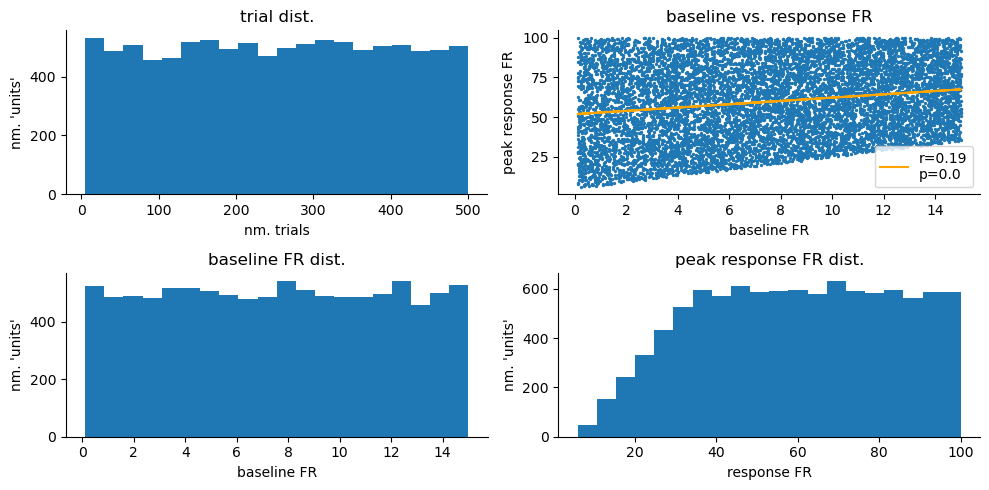

In [37]:
fig, axes = plt.subplots(2,2,figsize=(10,5))

ax = axes[0,0]
ax.hist(data["n_trials"], bins=20)
ax.set_title("trial dist.")
ax.set_xlabel("nm. trials")
ax.set_ylabel("nm. 'units'")
sns.despine(ax=ax)

ax = axes[0,1]
ax.scatter(data["fr_baseline"], data["fr_response"], s=2)

b, m = polyfit(data["fr_baseline"], data["fr_response"], 1)
r, p = pearsonr(data["fr_baseline"], data["fr_response"])
ax.plot(data["fr_baseline"], b + m * data["fr_baseline"], '-', c="orange", label=f"r={round(r, 3)}\np={round(p, 3)}")
ax.legend()

ax.set_title("baseline vs. response FR")
ax.set_xlabel("baseline FR")
ax.set_ylabel("peak response FR")
sns.despine(ax=ax)

ax = axes[1,0]
ax.hist(data["fr_baseline"], bins=20)
ax.set_title("baseline FR dist.")
ax.set_xlabel("baseline FR")
ax.set_ylabel("nm. 'units'")
sns.despine(ax=ax)

ax = axes[1,1]
ax.hist(data["fr_response"], bins=20)
ax.set_title("peak response FR dist.")
ax.set_xlabel("response FR")
ax.set_ylabel("nm. 'units'")
sns.despine(ax=ax)


plt.tight_layout()

In [ ]:
import numpy as np

import matplotlib.pyplot as plt

# Sample data
x = np.arange(10)
y = 5 * x + 10

# Fit with polyfit
b, m = polyfit(x, y, 1)

plt.plot(x, y, '.')
plt.plot(x, b + m * x, '-')
plt.show()

(array([ 4.,  4.,  7.,  2.,  7.,  6., 10.,  6.,  2.,  3.,  6.,  1.,  2.,
         7.,  3.,  6.,  7.,  4.,  6.,  7.]),
 array([  6. ,  30.7,  55.4,  80.1, 104.8, 129.5, 154.2, 178.9, 203.6,
        228.3, 253. , 277.7, 302.4, 327.1, 351.8, 376.5, 401.2, 425.9,
        450.6, 475.3, 500. ]),
 <BarContainer object of 20 artists>)

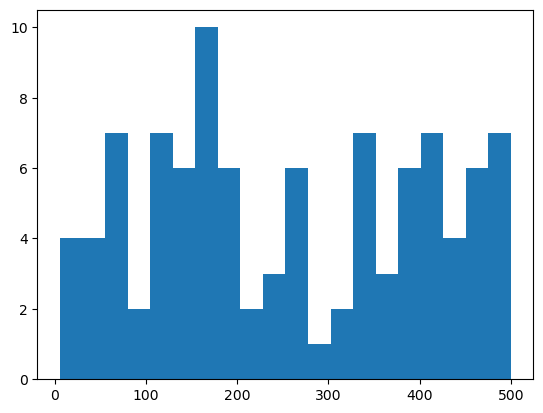

In [6]:
plt.hist(data["n_trials"], bins=20)

In [3]:
print("trial count values", np.unique(data["n_trials"]))
stat, p = pearsonr(data["n_trials"], data["fr_response"])
print(f"CORR - nm. trials and firing rate: r {round(stat, 3)}, p {round(p, 3)}")

trial count values [  8   9  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25
  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40  41  42  43
  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60  61
  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79
  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97
  98  99 100]
CORR - nm. trials and firing rate: r -0.001, p 0.966


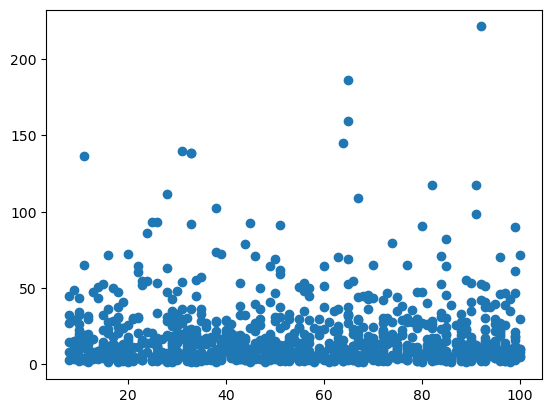

In [4]:
plt.scatter(np.abs(data["n_trials"]), data["fr_response"])


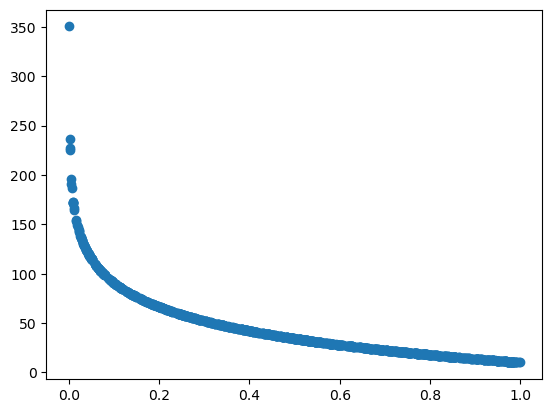

In [16]:

u = rng.uniform(size=1000)
plt.scatter(u, min_trial_num - scale_trial * np.log(u))

Pearson r = 0.106, p = 0.4642759560195243
[0.24014831 0.51754937 0.6663836  0.9771581  0.04884625 0.73009977
 0.80632537 0.69120674 0.3313921  0.15286543 0.54463341 0.93246837
 0.30596919 0.02314546 0.79786772 0.5817671  0.28184996 0.2047476
 0.26345823 0.86015458 0.04044645 0.86838525 0.86598926 0.21598175
 0.67401401 0.23613466 0.51958293 0.83236222 0.22332205 0.66860201
 0.76205275 0.93742871 0.51298664 0.00623352 0.36138226 0.00986445
 0.39273602 0.9573149  0.34873495 0.53038424 0.70935835 0.72803621
 0.66603066 0.8084193  0.0271724  0.34613094 0.53975913 0.2747486
 0.83129234 0.3229646 ]
[ 59  33  24  10 115  21  17  22  48  75  31  12  51 141  17  28  54  65
  56  15 122  14  15  63  23  60  32  16  62  24  19  12  33 187  45 171
  42  11  46  32  22  21  24  17 136  47  31  55  16  49]
[ 2.4039381   1.01136656  1.12628539  1.57974346  4.59860652  9.85491505
  1.62409173  1.04612928  3.74053677  2.6308168   9.04235287  1.46395018
  2.90128359  6.52675371  3.76090106  1.12321449  

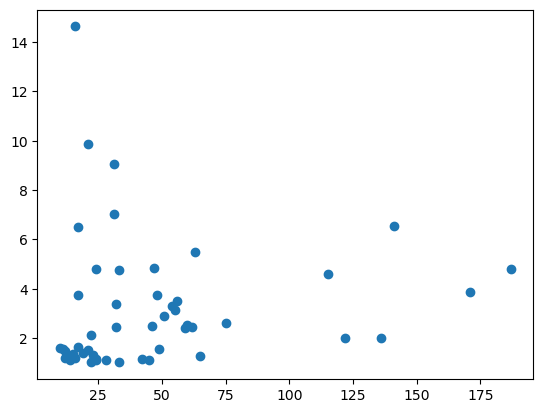

In [20]:
n_samples = 50
threshold = 1
scale = 3 

u = rng.uniform(size=n_samples)
fr_baseline = threshold - scale * np.log(u)

min_trial_num = 10
scale_trial = 35

u = rng.uniform(size=n_samples)
n_trials_list = np.array(min_trial_num - scale_trial * np.log(u), dtype=int)

plt.scatter(n_trials_list, fr_baseline)
r, p = pearsonr(n_trials_list, fr_baseline)
print(f"Pearson r = {r:.3f}, p = {p}")

print(u)
print(n_trials_list)
print(fr_baseline)

In [21]:
p

np.float64(0.4642759560195243)

In [ ]:
rng = np.random.default_rng(seed=73)

n_samples = 10
threshold = 1
scale = 3 



u = rng.uniform(size=n_samples)
fr_baseline = threshold - scale * np.log(u)

print(fr_baseline)

[ 3.12395299  4.57843064  4.94395586  1.04486233  5.54386654 11.32527548
  1.47102439  6.30135395  1.51107373  1.9720494 ]


In [5]:
from scipy.stats import pearsonr

x = np.abs(data["n_trials"])
y =  data["fr_baseline"]

r, p = pearsonr(x, y)
print(f"Pearson r = {r:.3f}, p = {p:.3e}")

Pearson r = 0.777, p = 1.276e-202
